# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

import importlib
import hw2code
importlib.reload(hw2code)
from hw2code import DecisionTree

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

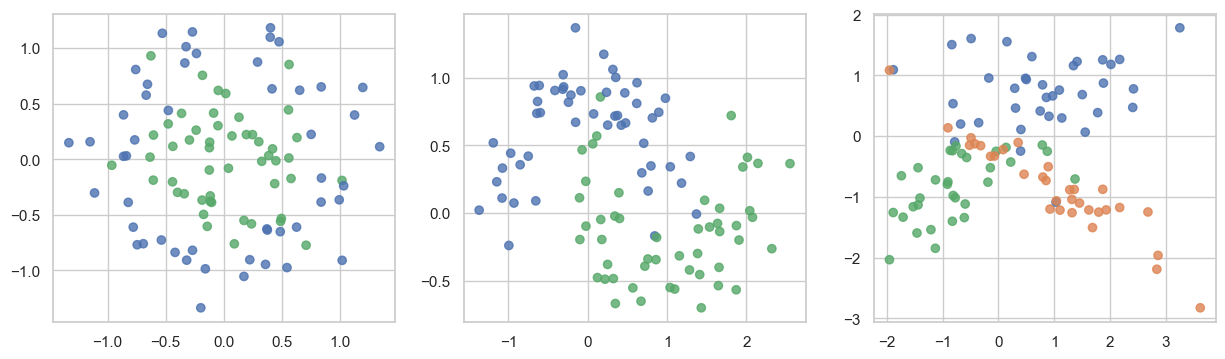

In [4]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [5]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

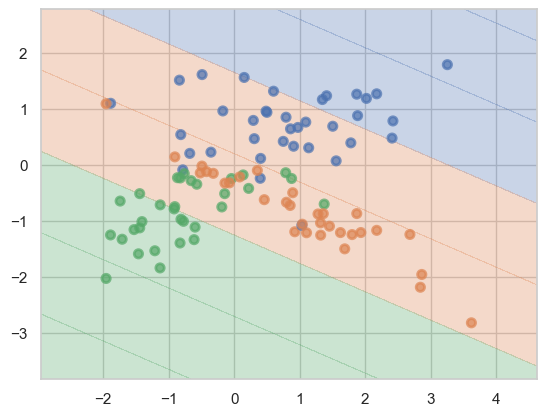

In [6]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

Dataset 1: train_accuracy = 1.000, test_accuracy = 0.700
Dataset 2: train_accuracy = 1.000, test_accuracy = 0.933
Dataset 3: train_accuracy = 1.000, test_accuracy = 0.667


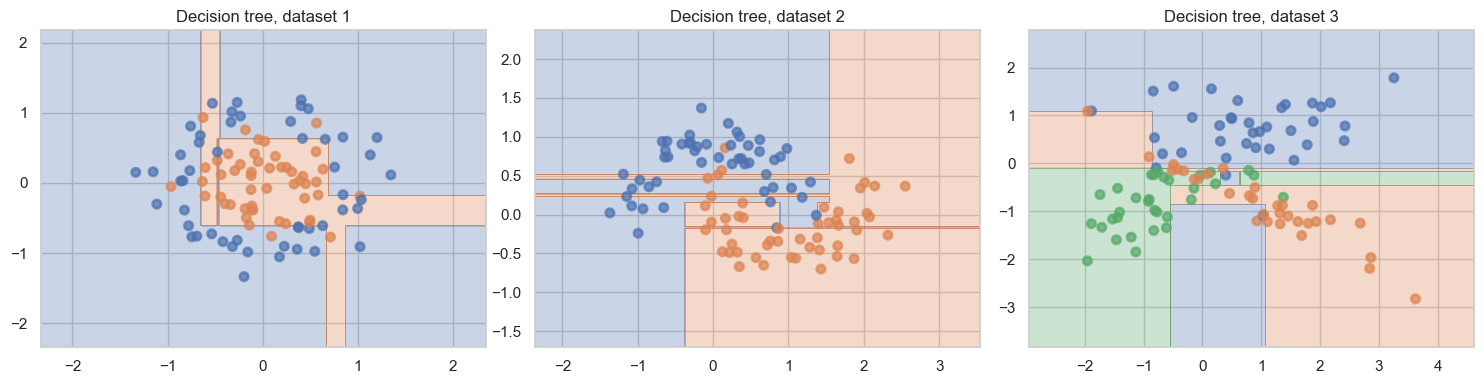

In [7]:
plt.figure(figsize=(15, 4))

for i, (X, y) in enumerate(datasets, start=1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    print(
        f"Dataset {i}: train_accuracy = {accuracy_score(y_train, y_train_pred):.3f}, "
        f"test_accuracy = {accuracy_score(y_test, y_test_pred):.3f}"
    )

    plt.subplot(1, 3, i)
    plot_surface(clf, X, y)
    plt.title(f"Decision tree, dataset {i}")

plt.tight_layout()
plt.show()


__Ответ:__ Со стандартными параметрами дерево идеально запоминает обучающую выборку (accuracy == 1.0 для всех датасетов), но значительно хуже правляется с тестовой выборкой. Также по графикам видно, что границы классов имеют причудливую излишне сложную форму. Отсюда можно сделать вывод, что деревья сильно переобучаются и просто запоминают тестовую выборку, вместо того чтобы выявлять закономерности

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

Dataset: 1
Max depth 2: train_accuracy = 0.800, test_accuracy = 0.625
Max depth 3: train_accuracy = 0.917, test_accuracy = 0.650
Max depth 4: train_accuracy = 0.983, test_accuracy = 0.725
Max depth 5: train_accuracy = 0.983, test_accuracy = 0.800
Max depth 6: train_accuracy = 1.000, test_accuracy = 0.775
Max depth 7: train_accuracy = 1.000, test_accuracy = 0.775


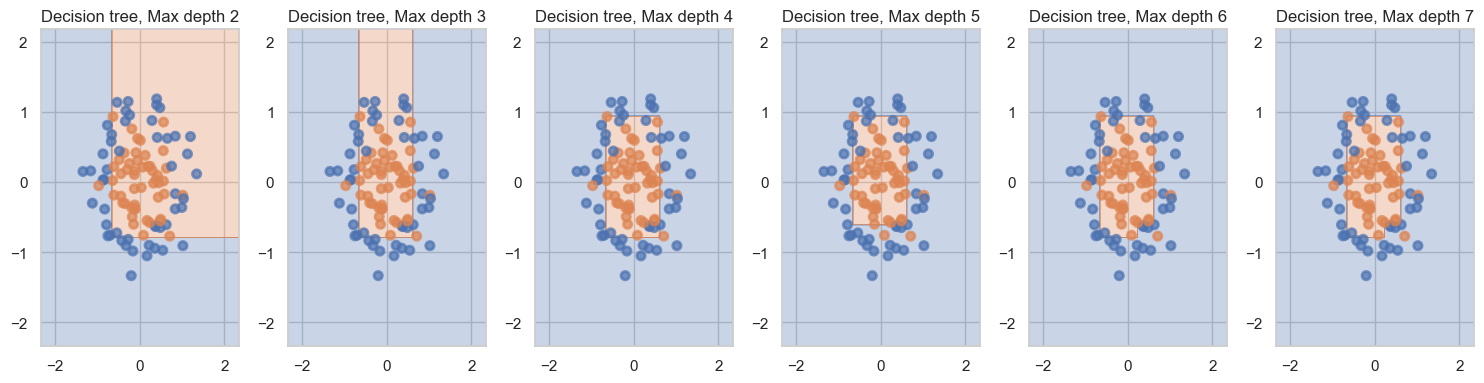

Dataset: 2
Max depth 2: train_accuracy = 0.833, test_accuracy = 0.825
Max depth 3: train_accuracy = 0.917, test_accuracy = 0.825
Max depth 4: train_accuracy = 0.950, test_accuracy = 0.825
Max depth 5: train_accuracy = 1.000, test_accuracy = 0.875
Max depth 6: train_accuracy = 1.000, test_accuracy = 0.875
Max depth 7: train_accuracy = 1.000, test_accuracy = 0.875


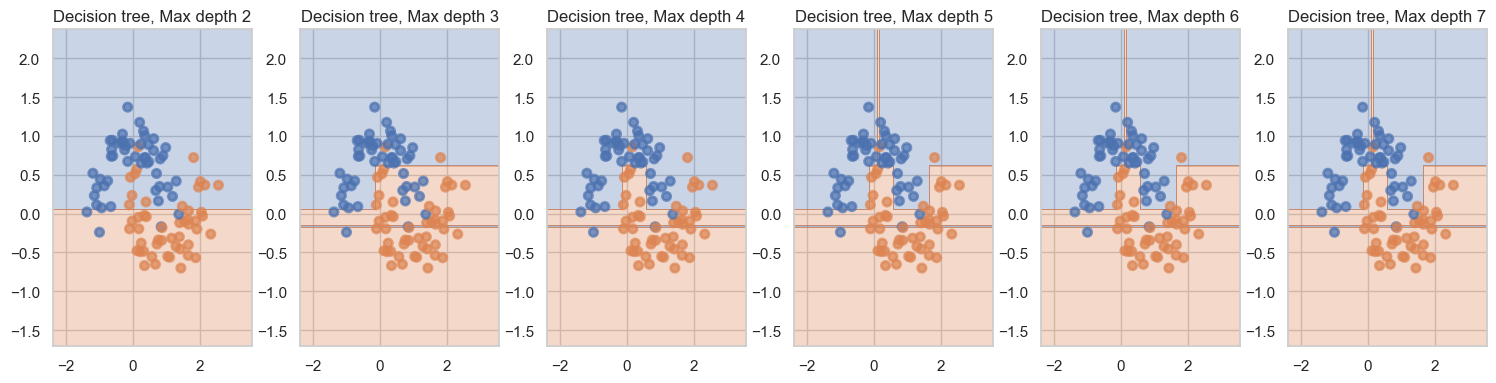

Dataset: 3
Max depth 2: train_accuracy = 0.900, test_accuracy = 0.825
Max depth 3: train_accuracy = 0.900, test_accuracy = 0.825
Max depth 4: train_accuracy = 0.900, test_accuracy = 0.825
Max depth 5: train_accuracy = 0.933, test_accuracy = 0.825
Max depth 6: train_accuracy = 0.950, test_accuracy = 0.800
Max depth 7: train_accuracy = 0.983, test_accuracy = 0.800


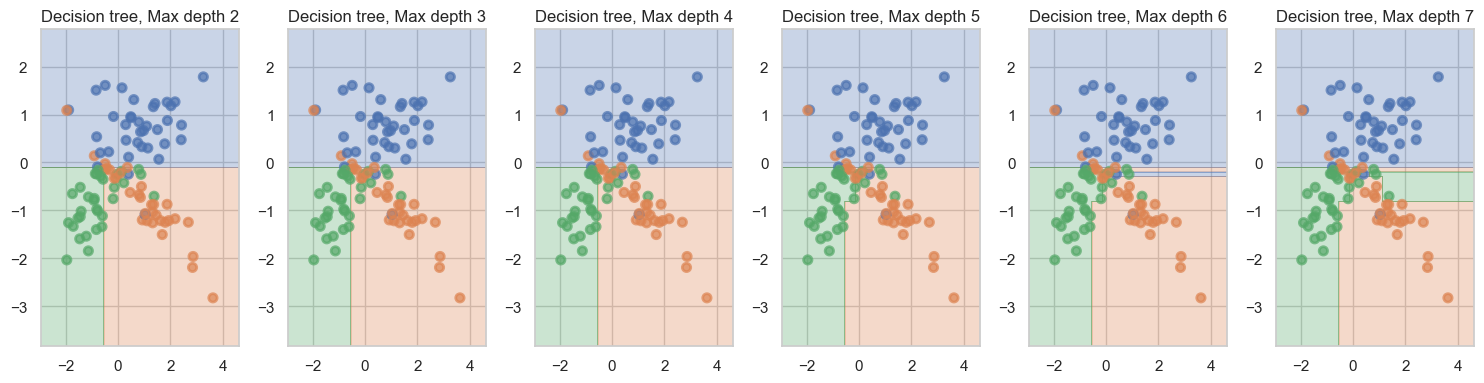

In [12]:
min_sample_leaf_range = list(range(2, 8))

for i, (X, y) in enumerate(datasets, start=1):
    plt.figure(figsize=(15, 4))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=43, stratify=y
    )
    print(f"Dataset: {i}")
    for j, max_depth in enumerate(min_sample_leaf_range, start=1):
        clf = DecisionTreeClassifier(random_state=42, max_depth=max_depth)

        clf.fit(X_train, y_train)
        y_train_pred = clf.predict(X_train)
        y_test_pred = clf.predict(X_test)

        print(
            f"Max depth {max_depth}: "
            f"train_accuracy = {accuracy_score(y_train, y_train_pred):.3f}, "
            f"test_accuracy = {accuracy_score(y_test, y_test_pred):.3f}"
        )

        plt.subplot(1, len(min_sample_leaf_range), j)
        plot_surface(clf, X, y)
        plt.title(f"Decision tree, Max depth {max_depth}")

    plt.tight_layout()
    plt.show()




__Вывод__ : При увеличении max_depth train_accuracy стабильно растет при любых вводных для всех датасетов, а test_accuracy обычно немного растет, а затем падает, что сведетельствует о переобучении. Однако при разных test_size и random_state и на разных датасетах test_accuracy ведет себя по разному : иногда может только расти или колебаться, пока не дойдет до плато (когда train_accuracy достигла 1.0, test_accuracy перестаёт меняться), но это скорее удачное совпадение, чем показатель качества

Dataset: 1
Min samples leaf 1: train_accuracy = 1.000, test_accuracy = 0.775
Min samples leaf 2: train_accuracy = 0.983, test_accuracy = 0.800
Min samples leaf 3: train_accuracy = 0.983, test_accuracy = 0.725
Min samples leaf 4: train_accuracy = 0.983, test_accuracy = 0.725
Min samples leaf 5: train_accuracy = 0.967, test_accuracy = 0.725
Min samples leaf 6: train_accuracy = 0.950, test_accuracy = 0.775


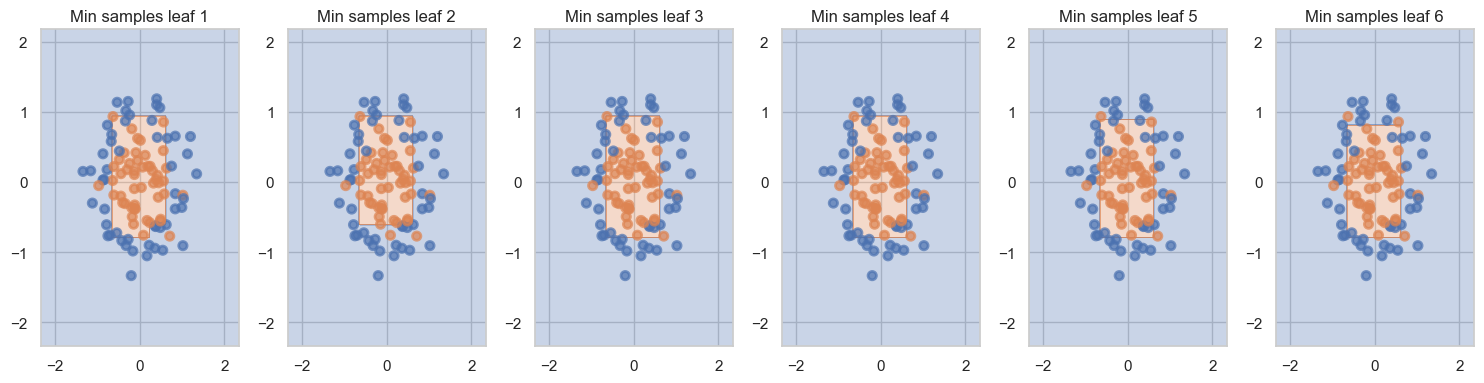

Dataset: 2
Min samples leaf 1: train_accuracy = 1.000, test_accuracy = 0.875
Min samples leaf 2: train_accuracy = 0.967, test_accuracy = 0.875
Min samples leaf 3: train_accuracy = 0.950, test_accuracy = 0.900
Min samples leaf 4: train_accuracy = 0.933, test_accuracy = 0.825
Min samples leaf 5: train_accuracy = 0.933, test_accuracy = 0.825
Min samples leaf 6: train_accuracy = 0.933, test_accuracy = 0.825


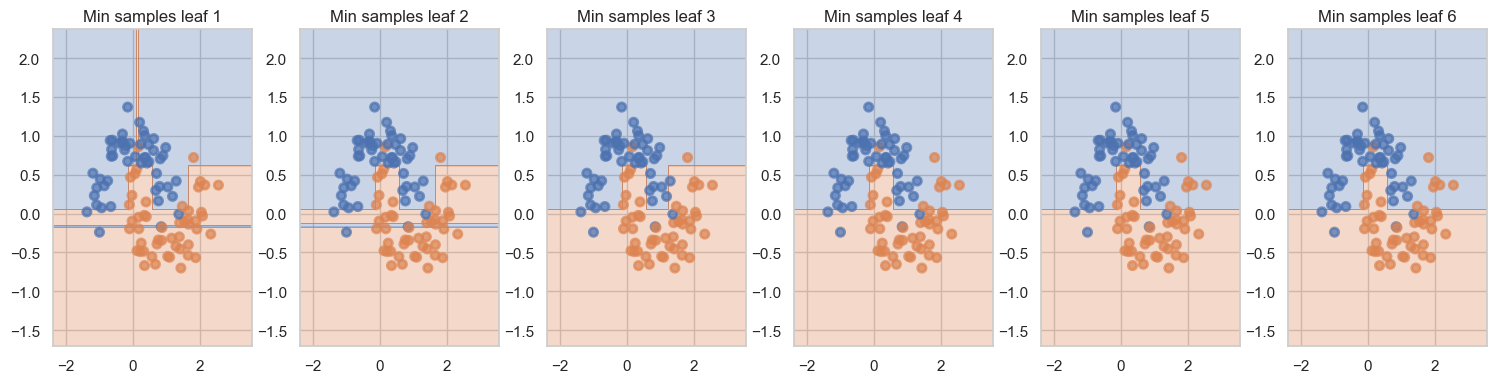

Dataset: 3
Min samples leaf 1: train_accuracy = 1.000, test_accuracy = 0.825
Min samples leaf 2: train_accuracy = 0.950, test_accuracy = 0.800
Min samples leaf 3: train_accuracy = 0.967, test_accuracy = 0.825
Min samples leaf 4: train_accuracy = 0.917, test_accuracy = 0.850
Min samples leaf 5: train_accuracy = 0.900, test_accuracy = 0.825
Min samples leaf 6: train_accuracy = 0.900, test_accuracy = 0.825


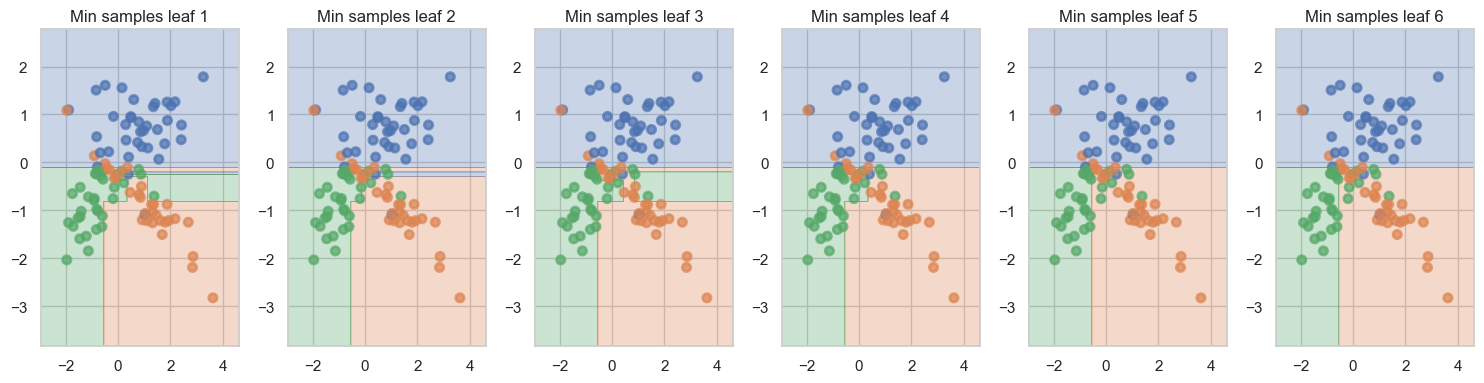

In [11]:
min_sample_leaf_range = list(range(1, 7))

for i, (X, y) in enumerate(datasets, start=1):
    plt.figure(figsize=(15, 4))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=43, stratify=y
    )
    print(f"Dataset: {i}")

    for j, min_samples_leaf in enumerate(min_sample_leaf_range, start=1):
        clf = DecisionTreeClassifier(random_state=42, min_samples_leaf=min_samples_leaf)

        
        clf.fit(X_train, y_train)
        y_train_pred = clf.predict(X_train)
        y_test_pred = clf.predict(X_test)

        print(
            f"Min samples leaf {min_samples_leaf}: "
            f"train_accuracy = {accuracy_score(y_train, y_train_pred):.3f}, "
            f"test_accuracy = {accuracy_score(y_test, y_test_pred):.3f}"
        )

        plt.subplot(1, len(min_sample_leaf_range), j)
        plot_surface(clf, X, y)
        plt.title(f"Min samples leaf {min_samples_leaf}")

    plt.tight_layout()
    plt.show()

__Вывод__ : При увеличении min_samples_leaf train_accuracy медленно уменьшается, а test_accuracy сначала увеличивается, потом также начинает снижаться

__Ответ:__ Слишком маленький max_depth или слишком большой min_samples_leaf делает модель слишком простой, при маленькой глубине модель не может проверить достаточно условий, чтобы отделить сложный по форме кусок,а при большом количестве элементов в листовом узле модель игнорирует небольшие скопления, которые при этом могут быть расположены в далеке от элементов других классов и быть легко отделимы. Большой max_depth и маленький min_samples_leaf приводят к переобучению, большая глубина дает возможность сильно дробить области, из-за чего элементы тестовой выборки могут легко "провалиться" между полосками нужного класса, а небольшое количество элементов в листе делает модель уязвимой к выбросам, она может посчитать выделение одного элемента класса A в облаке элементов класса B наиболее выгодным и ради одного элемента формируется целая полоса класса A, в которую легко попадают элементы класса B из тестовой выборки

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

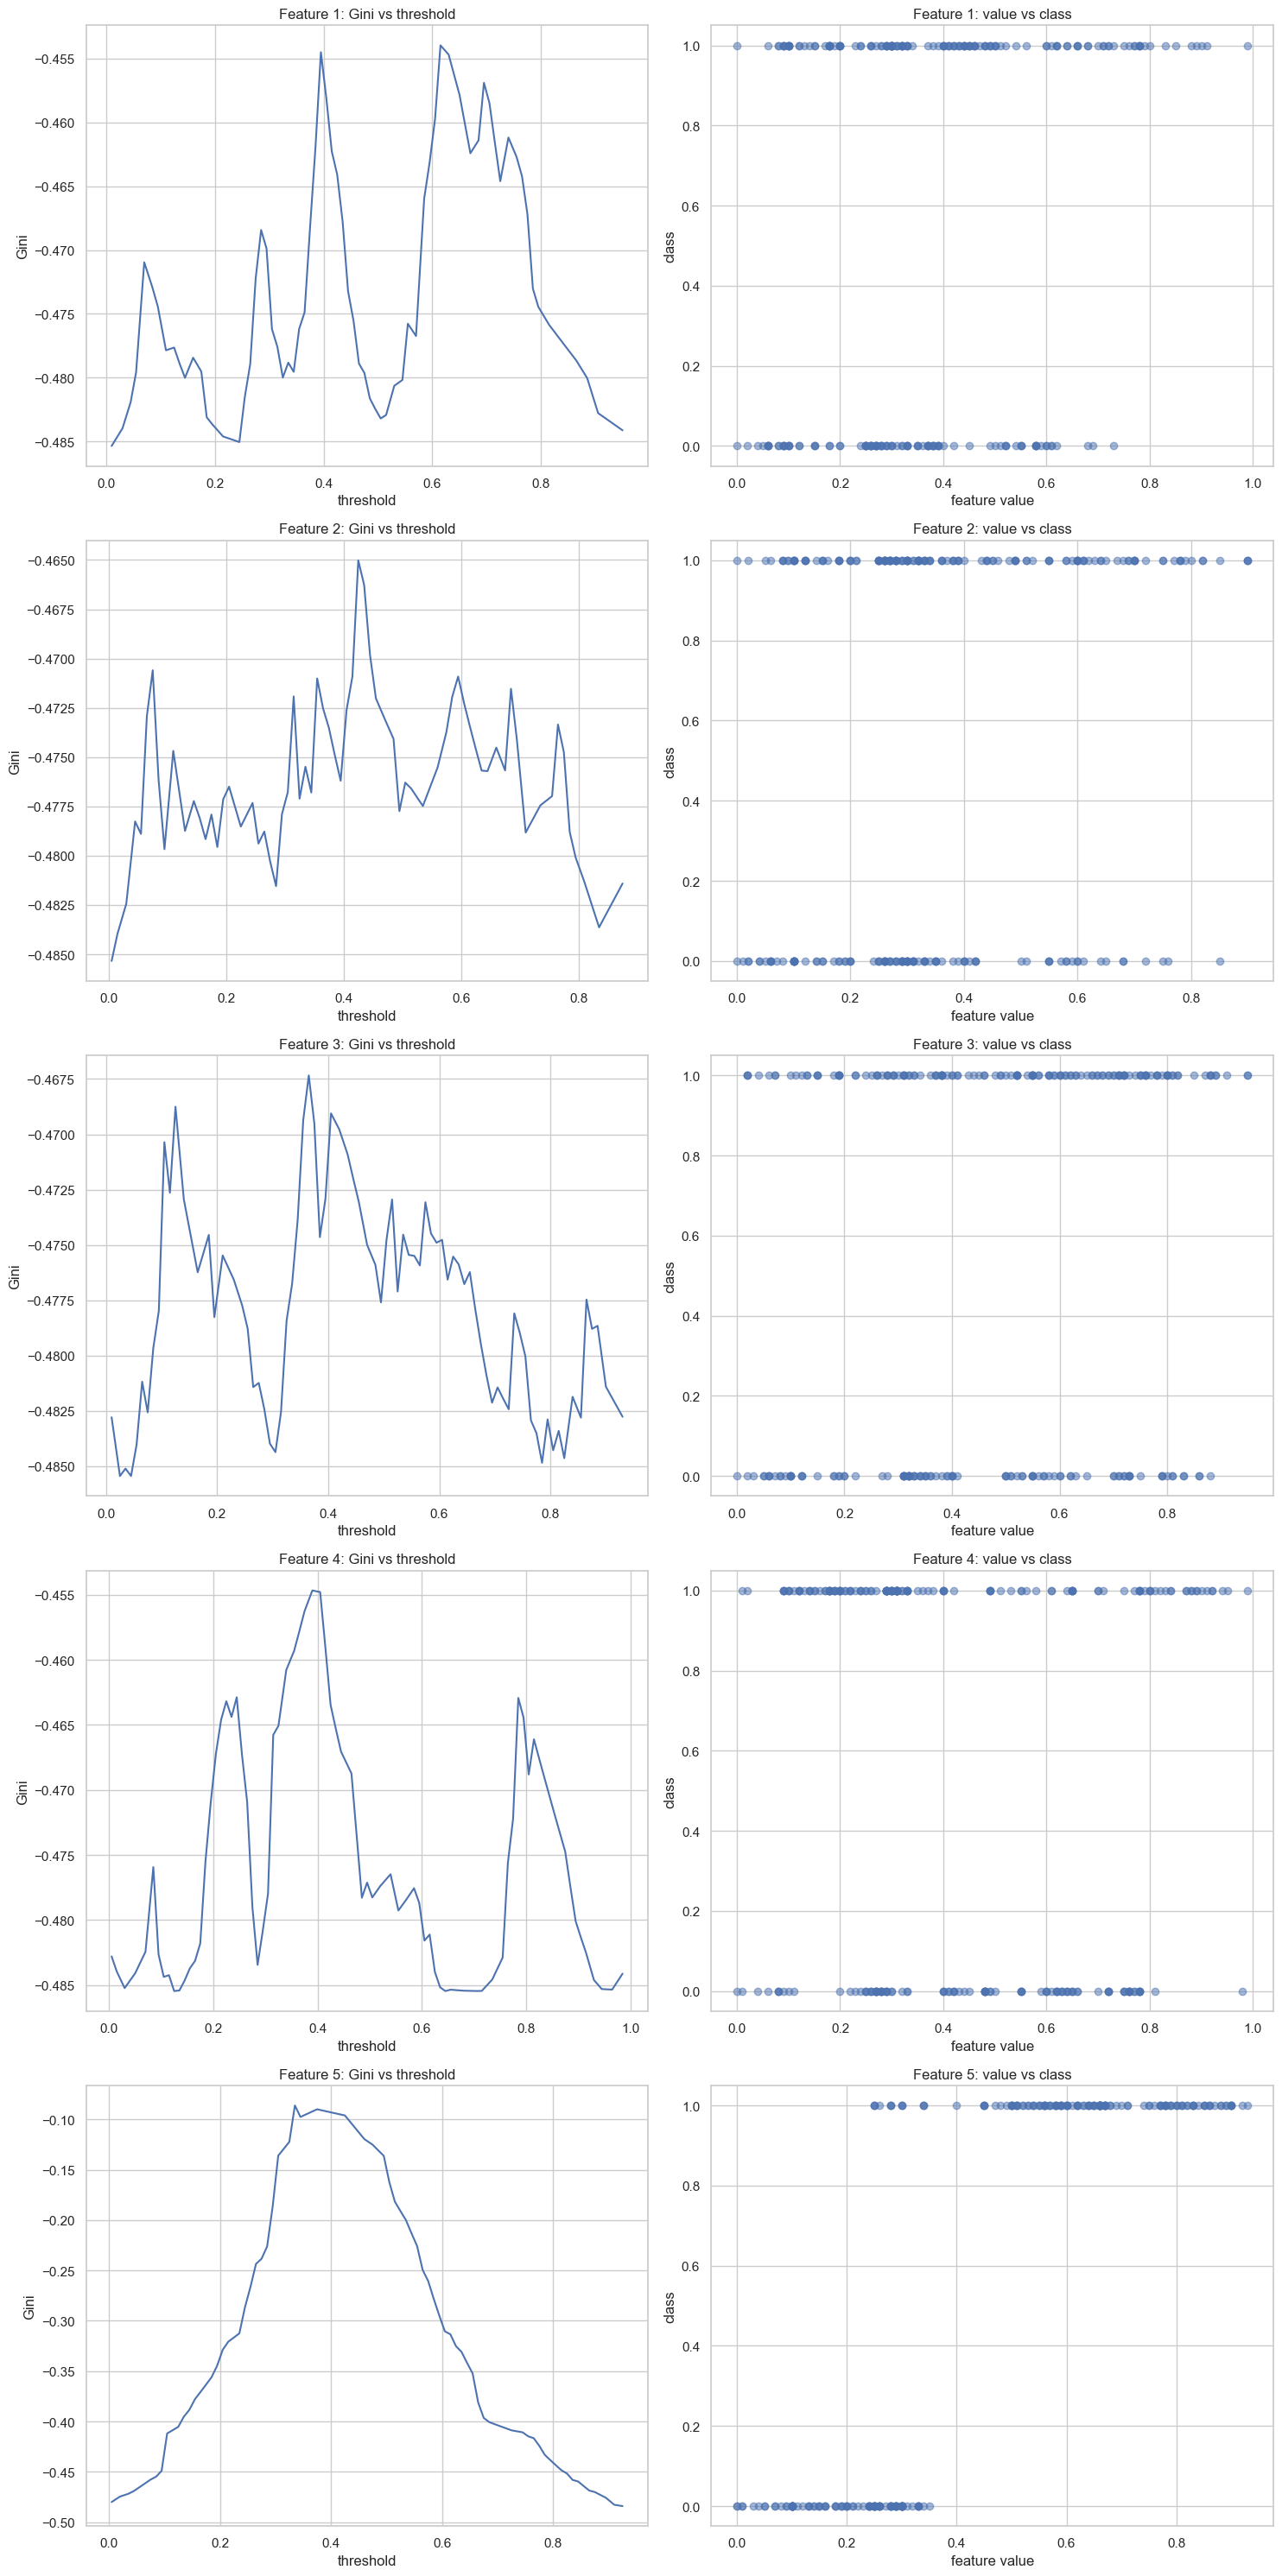

In [13]:
from hw2code import find_best_split

data = pd.read_csv("datasets/students.csv")
X = data.iloc[:, :5].values
y = data.iloc[:, -1].values

num_features = 5

plt.figure(figsize=(15, 30))

for i in range(num_features):

    plt.subplot(num_features, 2, 2 * i + 1)

    thresholds, ginis, _, _ = find_best_split(X[:, i], y)

    plt.plot(thresholds, ginis)
    plt.title(f"Feature {i+1}: Gini vs threshold")
    plt.xlabel("threshold")
    plt.ylabel("Gini")

    plt.subplot(num_features, 2, 2 * i + 2)

    plt.scatter(X[:, i], y, alpha=0.5)
    plt.title(f"Feature {i+1}: value vs class")
    plt.xlabel("feature value")
    plt.ylabel("class")

plt.tight_layout()
plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** Исходя из кривых критерия Джини делить нужно по 5 признаку, там значение критерия самое большое: около -0.1. Это согласуется со scatter-графиком: для признаков 1-4 на всём диапазоне есть объекты обоих классов, в то время как для 5 признака мы видмим что объекты класса 0 находятся скорее слева, а класса 1 скорее справа. Рассмотрев вид кривых критерия Джини, можно заметить, что для "плохих" признаков график содержит множество локальных минимумов и максимумов, но при этом сброс значений всего несколько сотых (от -0.48 до -0.45), т.е. любые пороговые значения почти одинаково плохи. А вот для "хорошего" признака 5 график заметно более плавный: сначала возрастает, затем убывает, конечно, это происходит не совсем монотонно, там есть 2 локальных максимума, но общую картину они сильно не нарушают, получается холм на вершине которого наилучший порог, при этом значения отличаются на десятые доли (от -0.5 до -0.1), а учитывая что значения критерия Джини для 2 классов лежат в диапозоне [-0.5, 0], это зачимое различие.

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [ ]:
df = pd.read_csv("datasets/agaricus-lepiota.data", header=None)

encoders = []
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders.append(le)

y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values

feature_types = ["categorical"] * X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    shuffle=True,
    stratify=y
)

clf = DecisionTree(feature_types=feature_types)
clf.fit(X_train, y_train)

# Предсказания
y_pred = clf.predict(X_test)

# Оценка качества
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print(clf._depth)


Accuracy: 1.0
7


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

In [21]:
df = pd.read_csv("datasets/tic-tac-toe-endgame.csv")

encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

X = df.iloc[:, :-1].values   # V1..V9
y = df.iloc[:, -1].values    # V10 (positive/negative → 0/1)

feature_types = ["categorical"] * X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

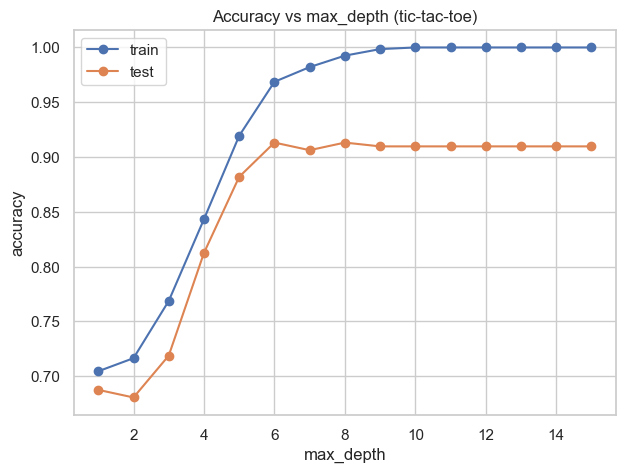

In [18]:
# max_depth
max_depth_values = list(range(1, 16))
train_acc_md = []
test_acc_md = []

for md in max_depth_values:
    clf = DecisionTree(
        feature_types=feature_types,
        max_depth=md
    )
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    train_acc_md.append(accuracy_score(y_train, y_train_pred))
    test_acc_md.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(7, 5))
plt.plot(max_depth_values, train_acc_md, marker="o", label="train")
plt.plot(max_depth_values, test_acc_md, marker="o", label="test")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Accuracy vs max_depth (tic-tac-toe)")
plt.legend()
plt.grid(True)
plt.show()

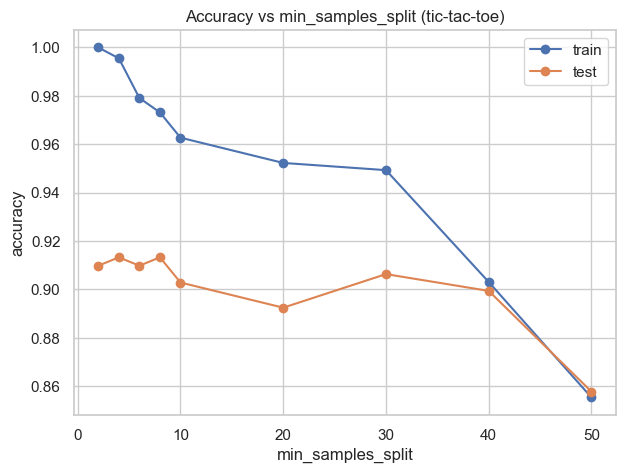

In [19]:
min_samples_split_values = [2, 4, 6, 8, 10, 20, 30, 40, 50]
train_acc_mss = []
test_acc_mss = []

for mss in min_samples_split_values:
    clf = DecisionTree(
        feature_types=feature_types,
        min_samples_split=mss
    )
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    train_acc_mss.append(accuracy_score(y_train, y_train_pred))
    test_acc_mss.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(7, 5))
plt.plot(min_samples_split_values, train_acc_mss, marker="o", label="train")
plt.plot(min_samples_split_values, test_acc_mss, marker="o", label="test")
plt.xlabel("min_samples_split")
plt.ylabel("accuracy")
plt.title("Accuracy vs min_samples_split (tic-tac-toe)")
plt.legend()
plt.grid(True)
plt.show()

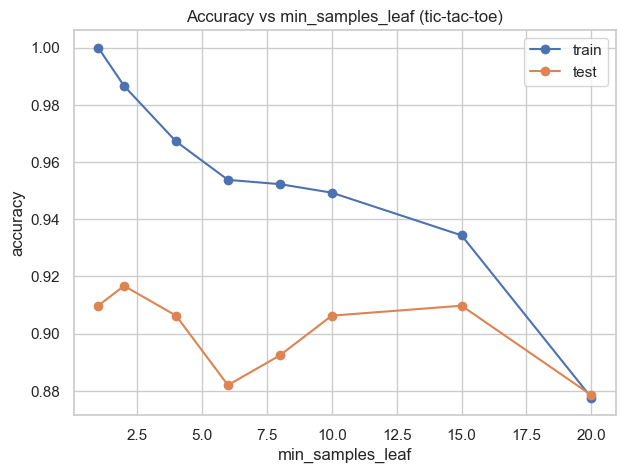

In [20]:
min_samples_leaf_values = [1, 2, 4, 6, 8, 10, 15, 20]
train_acc_mss = []
test_acc_mss = []

for msl in min_samples_leaf_values:
    clf = DecisionTree(
        feature_types=feature_types,
        min_samples_leaf=msl
    )
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    train_acc_mss.append(accuracy_score(y_train, y_train_pred))
    test_acc_mss.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(7, 5))
plt.plot(min_samples_leaf_values, train_acc_mss, marker="o", label="train")
plt.plot(min_samples_leaf_values, test_acc_mss, marker="o", label="test")
plt.xlabel("min_samples_leaf")
plt.ylabel("accuracy")
plt.title("Accuracy vs min_samples_leaf (tic-tac-toe)")
plt.legend()
plt.grid(True)
plt.show()

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [47]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder

In [38]:
# mushrums

mush = pd.read_csv("datasets/agaricus-lepiota.data", header=None)

encoders_mush = {}
for col in mush.columns:
    le = LabelEncoder()
    mush[col] = le.fit_transform(mush[col].astype(str))
    encoders_mush[col] = le

y_mush = mush.iloc[:, 0].values
X_mush = mush.iloc[:, 1:].values

# tic-tac-toe

xoxo = pd.read_csv("datasets/tic-tac-toe-endgame.csv")

encoders_xoxo = {}
for col in xoxo.columns:
    le = LabelEncoder()
    xoxo[col] = le.fit_transform(xoxo[col].astype(str))
    encoders_xoxo[col] = le

X_xoxo = xoxo.iloc[:, :-1].values
y_xoxo = xoxo.iloc[:, -1].values

# cars

cars = pd.read_csv("datasets/car.data", header=None)
encoders_cars_X = {}
for col in cars.columns[:-1]:
    le = LabelEncoder()
    cars[col] = le.fit_transform(cars[col].astype(str))
    encoders_cars_X[col] = le

y_cars_raw = cars.iloc[:, -1].astype(str).values

y_cars = np.where(np.isin(y_cars_raw, ["unacc", "acc"]), 0, 1)

X_cars = cars.iloc[:, :-1].values

# nurses

nur = pd.read_csv("datasets/nursery.data", header=None)

from sklearn.preprocessing import LabelEncoder

encoders_nur_X = {}
for col in nur.columns[:-1]:
    le = LabelEncoder()
    nur[col] = le.fit_transform(nur[col].astype(str))
    encoders_nur_X[col] = le

y_nur_raw = nur.iloc[:, -1].astype(str).values

y_nur = np.where(np.isin(y_nur_raw, ["not_recom", "recommend"]), 0, 1)

X_nur = nur.iloc[:, :-1].values

# datasets

datasets = {
    "mushrooms" : (X_mush, y_mush),
    "tic-tac-toe" : (X_xoxo, y_xoxo),
    "nursery" : (X_nur, y_nur),
    "cars" : (X_cars, y_cars)
}

In [53]:
results = []

scorer = make_scorer(accuracy_score)
cv = KFold(n_splits=10, shuffle=True, random_state=2)
# cv = 10

for name, (X, y) in datasets.items():

    print("Processing:", name)

    feature_types_real = ["real"] * X.shape[1]
    clf_real = DecisionTree(feature_types=feature_types_real)
    acc_real = cross_val_score(clf_real, X, y, cv=cv, scoring=scorer).mean()

    feature_types_cat = ["categorical"] * X.shape[1]
    clf_cat = DecisionTree(feature_types=feature_types_cat)
    acc_cat = cross_val_score(clf_cat, X, y, cv=cv, scoring=scorer).mean()

    ohe = OneHotEncoder(sparse_output=False)
    X_ohe = ohe.fit_transform(X)
    feature_types_ohe = ["real"] * X_ohe.shape[1]
    clf_ohe = DecisionTree(feature_types=feature_types_ohe)
    acc_ohe = cross_val_score(clf_ohe, X_ohe, y, cv=cv, scoring=scorer).mean()

    clf_sklearn = DecisionTreeClassifier(random_state=42)
    acc_sklearn = cross_val_score(clf_sklearn, X, y, cv=cv, scoring=scorer).mean()

    results.append([name, acc_real, acc_cat, acc_ohe, acc_sklearn])


columns = [
    "dataset",
    "my_tree_real",
    "my_tree_categorical",
    "my_tree_onehot",
    "sklearn_tree"
]

df_results = pd.DataFrame(results, columns=columns)
df_results    

Processing: mushrooms
Processing: tic-tac-toe
Processing: nursery
Processing: cars


,dataset,my_tree_real,my_tree_categorical,my_tree_onehot,sklearn_tree
0,mushrooms,1.000000,1.000000,1.000000,1.000000
1,tic-tac-toe,0.889309,0.951941,0.952982,0.888268
2,nursery,0.999537,0.999769,0.999769,0.999537
3,cars,0.993047,0.993047,0.988412,0.991887


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:** На разных датасетах алгоритмы действительно ранжируются по-разному, что связано с различной структурой признаков. На mushrooms и nursery задача легко раскладывается деревьями: все методы дают accuracy ≈ 1.0, так как признаки формируют почти идеальные разбиения. В tic-tac-toe ситуация иная — важны не отдельные клетки, а их комбинации, поэтому качество у разных вариантов нашего дерева заметно отличается; лучшими оказываются my_tree_categorical и my_tree_onehot, тогда как sklearn показывает чуть худший результат, вероятно из-за менее подходящей логики работы с категориальными признаками в этом датасете. В cars различия небольшие, но опять же маленькое преимущество у категориальной версии нашего дерева, так как она корректнее использует структуру категорий. В целом видно, что my_tree_categorical — наиболее стабильный вариант. Компонента случайности присутсвует в разбиении KFold, на случайность можно повлиять задав random_state, можно перебором подобрать значение по удачнее, но само по себе наличие случайного перемешивания может улучшить работу алгоритма, например в случае tic-tac-toe без перемешивая accuracy был около 0.54, а с ним 0.95, потому что изначально датасет упорядочен по таргету.

Вставьте что угодно, описывающее ваши впечатления от этого задания:

Было прикольно своими руками потрогать как работают решающие деревья, читать как их обучать это одна, а самостоятельно по графикам смотреть как они получаются это совсем другой уровень понимания